# Assignment 2: The "Smart Labeling Pipeline" Challenge

**Total Marks: 20**

Build a cost-effective, high-quality labeling pipeline using human annotation, programmatic rules, and LLMs.

This notebook implements an end-to-end smart labeling pipeline to:
1. Establish gold standard through human annotation and measure inter-annotator agreement (6 marks)
2. Label data programmatically using weak supervision (Snorkel) (6 marks)
3. Optimize labeling budget using active learning (5 marks)
4. Leverage LLMs for bulk labeling and detect hallucinations (e.g. noisy labels) (3 marks)

In [30]:
pip install snorkel

## Setup and Imports

In [31]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel
from statsmodels.stats.inter_rater import fleiss_kappa
import google.generativeai as genai
import time
from pathlib import Path
import re
import matplotlib.pyplot as plt
import os
import json
import requests
from IPython.display import display
from dotenv import load_dotenv


## Task 1: The Human as Annotator (6 Marks)

**Objective:** Establish a "Gold Standard" dataset and measure human consensus.

### Part 1.1: Parse Annotator CSV Files

After annotating the first 100 reviews, export annotations from three annotators (A, B, C) as CSV files.
Parse these CSV files into clean DataFrames for analysis.

In [32]:
def parse_annotator_csv(csv_path):
    df = pd.read_csv(csv_path)

    if 'text' in df.columns:
        df['review'] = df['text']
    elif 'review' not in df.columns and 'content' in df.columns:
        df['review'] = df['content']

    if 'annotation' in df.columns:
        df['label'] = df['annotation']
    elif 'label' not in df.columns and 'prediction' in df.columns:
        df['label'] = df['prediction']

    # Keep only review_id, review, label
    df = df[['annotation_id', 'review', 'sentiment']].dropna()
    return df[['review', 'sentiment']]


In [33]:
df_a = parse_annotator_csv('annotator_a.csv')
df_b = parse_annotator_csv('annotator_b.csv')
df_c = parse_annotator_csv('annotator_c.csv')


print("Annotator A sample:")
display(df_a.head())
print()

print("Annotator B sample:")
display(df_b.head())
print()

print("Annotator C sample:")
display(df_c.head())
print()


Annotator A sample:


,review,sentiment
0,This movie is a triumph in every sense. Highly...,Positive
1,I have never been so bored in my life. The sco...,Negative
2,I was completely blown away by this film. The ...,Positive
3,The trailer was better than the movie. The act...,Negative
4,Middle of the road entertainment. Visually it'...,Neutral



Annotator B sample:


,review,sentiment
0,This movie is a triumph in every sense. Highly...,Positive
1,I have never been so bored in my life. The sco...,Negative
2,I was completely blown away by this film. The ...,Positive
3,The trailer was better than the movie. The act...,Neutral
4,Middle of the road entertainment. Visually it'...,Neutral



Annotator C sample:


,review,sentiment
1,This movie is a triumph in every sense. Highly...,Positive
3,I have never been so bored in my life. The sco...,Negative
5,I was completely blown away by this film. The ...,Positive
7,The trailer was better than the movie. The act...,Negative
9,Middle of the road entertainment. Visually it'...,Negative


### Part 1.2: Implement Fleiss' Kappa from Scratch

Measure inter-annotator agreement using Fleiss' Kappa statistic.
Implement the formula from scratch and compare with statsmodels implementation.

In [34]:
def fleiss_kappa_scratch(rating_matrix):
    N, k = rating_matrix.shape  # N items, k categories

    # Get number of raters per item
    n_per_item = rating_matrix.sum(axis=1)
    n_total = rating_matrix.sum()  # Total rater assignments

    # average observed agreement
    P_i = np.sum(rating_matrix * (rating_matrix - 1), axis=1) / (n_per_item * (n_per_item - 1))
    P_bar = np.mean(P_i)

    # expected agreement by chance
    p_j = rating_matrix.sum(axis=0) / n_total  # Total assignments per category
    P_e_bar = np.sum(p_j ** 2)

    # Kappa formula
    denominator = 1 - P_e_bar
    kappa = (P_bar - P_e_bar) / denominator if denominator != 0 else 0

    return kappa

In [35]:
def prepare_rating_matrix(df_a, df_b, df_c):
    df_a = df_a.rename(columns={'sentiment': 'label'})
    df_b = df_b.rename(columns={'sentiment': 'label'})
    df_c = df_c.rename(columns={'sentiment': 'label'})

    # Merge A and B first
    df_merged = df_a.merge(df_b, on='review', how='inner', suffixes=('_A', '_B'))

    # Merge with C
    df_merged = df_merged.merge(df_c.rename(columns={'label': 'label_C'}),
                               on='review', how='inner')

    print(f"----Merged {len(df_merged)} reviews from all 3 annotators----\n")

    categories = ['Negative', 'Neutral', 'Positive']
    cat_to_idx = {cat: i for i, cat in enumerate(categories)}

    N = len(df_merged)
    rating_matrix = np.zeros((N, 3))

    for i in range(N):
        labels = [df_merged.iloc[i]['label_A'],
                 df_merged.iloc[i]['label_B'],
                 df_merged.iloc[i]['label_C']]

        for label in labels:
            if pd.notna(label) and label in cat_to_idx:
                idx = cat_to_idx[label]
                rating_matrix[i, idx] += 1

    # rating matrix summary
    print("Rating Matrix Summary:")
    print(f"Shape: {rating_matrix.shape}")
    print(f"Raters per item: min={rating_matrix.sum(axis=1).min()}, max={rating_matrix.sum(axis=1).max()}")
    print(f"Category totals: {rating_matrix.sum(axis=0)}")

    return rating_matrix


rating_matrix = prepare_rating_matrix(df_a, df_b, df_c)

kappa_scratch = fleiss_kappa_scratch(rating_matrix)

# Statsmodels version
from statsmodels.stats.inter_rater import fleiss_kappa
kappa_statsmodels = fleiss_kappa(rating_matrix)

print(f"\nFleiss' Kappa Results:")
print(f"Scratch Implementation: {kappa_scratch:.4f}")
print(f"Statsmodels Implementation: {kappa_statsmodels:.4f}")
print(f"Difference: {abs(kappa_scratch - kappa_statsmodels):.6f}")

----Merged 100 reviews from all 3 annotators----

Rating Matrix Summary:
Shape: (100, 3)
Raters per item: min=3.0, max=3.0
Category totals: [ 83. 124.  93.]

Fleiss' Kappa Results:
Scratch Implementation: 0.7868
Statsmodels Implementation: 0.7868
Difference: 0.000000


### Part 1.3: Conflict Resolution

Identify conflicts where annotators disagree and resolve them using majority vote.
For complete ties (all three differ), default to 'Neutral'.

In [36]:
def resolve_conflicts(df_a, df_b, df_c):
    df_a = df_a.rename(columns={'sentiment': 'label'})
    df_b = df_b.rename(columns={'sentiment': 'label'})
    df_c = df_c.rename(columns={'sentiment': 'label'})

    # Merge all three DataFrames on 'review'
    df_merged = df_a.merge(df_b, on='review', how='inner', suffixes=('_A', '_B'))
    df_merged = df_merged.merge(df_c.rename(columns={'label': 'label_C'}),
                               on='review', how='inner')

    def majority_vote(row):
        labels = [row['label_A'], row['label_B'], row['label_C']]
        valid_labels = [label for label in labels if pd.notna(label)]

        if len(valid_labels) == 0:
            return 'Neutral'

        # Count votes
        from collections import Counter
        label_counts = Counter(valid_labels)

        # Check if any label has >2 votes
        max_count = max(label_counts.values())
        if max_count >= 2:
            # Return the majority label
            for label, count in label_counts.items():
                if count == max_count:
                    return label
        return 'Neutral'

    # Apply majority vote
    df_merged['majority label'] = df_merged.apply(majority_vote, axis=1)
    return df_merged[['review', 'majority label']]


In [37]:
gold_standard = resolve_conflicts(df_a, df_b, df_c)
print(f"Gold standard created: {len(gold_standard)} reviews")
print("\nSample resolved labels:")
display(gold_standard.head())

print("\nFinding conflict examples")
df_a_label = df_a.rename(columns={'sentiment': 'label'}).rename(columns={'label': 'label_A'})
df_b_label = df_b.rename(columns={'sentiment': 'label'}).rename(columns={'label': 'label_B'})
df_c_label = df_c.rename(columns={'sentiment': 'label'}).rename(columns={'label': 'label_C'})

# Merge to see original labels
conflicts_merged = gold_standard.merge(df_a_label, on='review', how='left')
conflicts_merged = conflicts_merged.merge(df_b_label, on='review', how='left')
conflicts_merged = conflicts_merged.merge(df_c_label, on='review', how='left')

# Find conflicts
conflicts_merged['all_agree'] = (
    (conflicts_merged['label_A'] == conflicts_merged['label_B']) &
    (conflicts_merged['label_A'] == conflicts_merged['label_C'])
)
conflicts = conflicts_merged[~conflicts_merged['all_agree']]

print(f"\nConflicts found: {len(conflicts)} out of {len(gold_standard)}")
if len(conflicts) >= 5:
    print("\n5 Examples of Conflicting Reviews:")
    display(conflicts[['review', 'label_A', 'label_B', 'label_C', 'majority label']].head())

else:
    print("\nAll conflict examples:")
    display(conflicts[['review', 'label_A', 'label_B', 'label_C', 'majority label']].head())


# Save gold standard
gold_standard.to_csv('gold_standard_100.csv', index=False)
print("\n Saved gold_standard_100.csv")

Gold standard created: 100 reviews

Sample resolved labels:


,review,majority label
0,This movie is a triumph in every sense. Highly...,Positive
1,I have never been so bored in my life. The sco...,Negative
2,I was completely blown away by this film. The ...,Positive
3,The trailer was better than the movie. The act...,Negative
4,Middle of the road entertainment. Visually it'...,Neutral



Finding conflict examples

Conflicts found: 20 out of 100

5 Examples of Conflicting Reviews:


,review,label_A,label_B,label_C,majority label
3,The trailer was better than the movie. The act...,Negative,Neutral,Negative,Negative
4,Middle of the road entertainment. Visually it'...,Neutral,Neutral,Negative,Neutral
15,"The direction was typical, but nothing special...",Neutral,Neutral,Negative,Neutral
31,This is a very difficult movie to categorize. ...,Neutral,Negative,Neutral,Neutral
35,"The acting is fine, but the story arc is a bit...",Neutral,Negative,Positive,Neutral



 Saved gold_standard_100.csv


## Task 2: Weak Supervision (The "Lazy" Labeler) (6 Marks)

**Objective:** Label the next 200 reviews programmatically to save time.

### Part 2.1: Heuristic Development

Analyze patterns in the gold standard and write at least 3 heuristic functions.
Apply them to the remaining 200 unlabeled reviews.

In [38]:

# Values for labeling functions
POSITIVE = 1
NEGATIVE = 0
NEUTRAL  = 2
ABSTAIN  = -1

# Load gold standard csv to analyze patterns
gold_df = pd.read_csv("gold_standard_100.csv")

print("Gold standard first 5 reviews:")
display(gold_df.head())

# If labels are text, normalize them
if gold_df['majority label'].dtype == 'object':
    gold_df['label_norm'] = gold_df['majority label'].str.strip().str.capitalize()
else:
    # Map numeric back to names if needed
    mapping_inv = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
    gold_df['label_norm'] = gold_df['label'].map(mapping_inv)
print("-"*100)
# Quick label distribution
print("\nLabel distribution in gold standard:")
display(gold_df['label_norm'].value_counts())

# Keyword-based exploration - stopwords are not removed, like the,in, as etc.
# def top_words_for_label(df, label, n=15):
#     from collections import Counter
#     texts = df[df['label_norm'] == label]['review'].astype(str).str.lower()
#     words = []
#     for t in texts:
#         words.extend(t.split())
#     common = Counter(words).most_common(n)
#     print(f"\nTop {n} words for {label}:")
#     for w, c in common:
#         print(f"{w}: {c}")

def top_words_for_label(df, label, n=15):
    from collections import Counter
    texts = df[df['label_norm'] == label]['review'].astype(str).str.lower()
    words = []
    for t in texts:
        words.extend([w for w in t.split() if w not in ENGLISH_STOP_WORDS])
    common = Counter(words).most_common(n)
    print(f"\nTop {n} words for {label}:")
    for w, c in common:
        print(f"{w}: {c}")

print("-"*100)
top_words_for_label(gold_df, 'Positive', n=15)
print("-"*100)
top_words_for_label(gold_df, 'Negative', n=15)
print("-"*100)
top_words_for_label(gold_df, 'Neutral',  n=15)
print("-"*100)

# Example: look at length distributions
gold_df['length_words'] = gold_df['review'].astype(str).str.split().str.len()
print("\nAverage length (in words) by label:")
display(gold_df.groupby('label_norm')['length_words'].mean())

Gold standard first 5 reviews:


,review,majority label
0,This movie is a triumph in every sense. Highly...,Positive
1,I have never been so bored in my life. The sco...,Negative
2,I was completely blown away by this film. The ...,Positive
3,The trailer was better than the movie. The act...,Negative
4,Middle of the road entertainment. Visually it'...,Neutral


----------------------------------------------------------------------------------------------------

Label distribution in gold standard:


,count
label_norm,
Neutral,45
Positive,30
Negative,25


----------------------------------------------------------------------------------------------------

Top 15 words for Positive:
movie: 8
triumph: 5
sense.: 5
perfectly: 5
balances: 5
humor: 5
drama.: 5
don't: 5
miss: 5
one.: 5
lead: 4
actor: 4
delivered: 4
performance.: 4
just: 4
----------------------------------------------------------------------------------------------------

Top 15 words for Negative:
complete: 8
misfire.: 5
bored: 4
life.: 4
frankly: 4
movie.: 4
zero: 4
stars: 4
it.: 4
like: 4
avoid: 3
costs.: 3
worked.: 3
waste: 3
potential.: 3
----------------------------------------------------------------------------------------------------

Top 15 words for Neutral:
it’s: 13
experience: 7
acting: 6
confused: 6
feel.: 6
fine,: 5
rest: 5
just: 4
oscillated: 4
loving: 4
hating: 4
film.: 4
tries: 4
deep,: 4
comes: 4
----------------------------------------------------------------------------------------------------

Average length (in words) by label:


,length_words
label_norm,
Negative,14.880000
Neutral,18.044444
Positive,16.833333


### Part 2.2: Snorkel Labeling Functions

Wrap your heuristics as Snorkel @labeling_function decorators.
Each function should return POSITIVE (1), NEGATIVE (0), NEUTRAL (2), or ABSTAIN (-1).

In [39]:

# Load the full 300 reviews dataframe
all_df = pd.read_csv("movie_reviews_300.csv")

if 'review' not in all_df.columns:
    raise ValueError("movie_reviews_300.csv must have a 'review' column")

# Use text of gold standard to exclude first 100 (already labeled)
gold_texts = set(gold_df['review'].astype(str))
unlabeled_200 = all_df[~all_df['review'].astype(str).isin(gold_texts)].copy()
unlabeled_200 = unlabeled_200.head(200)   # in case more than 200 reviews remain
print(f"\nUnlabeled Pool Size: {len(unlabeled_200)}")

# Labeling Functions (at least 3 we need, here we are giving 6)

positive_keywords = ["great", "excellent", "amazing", "fantastic", "brilliant", "wonderful", "loved", "awesome", "superb", "masterpiece"]

negative_keywords = ["bad", "terrible", "awful", "horrible", "worst","boring", "waste", "ridiculous", "trash", "poor"]

neutral_markers = ["okay", "average", "fine", "decent", "mediocre"]

@labeling_function()
def lf_pos_keywords(x):
    text = str(x.review).lower()
    return POSITIVE if any(w in text for w in positive_keywords) else ABSTAIN

@labeling_function()
def lf_neg_keywords(x):
    text = str(x.review).lower()
    return NEGATIVE if any(w in text for w in negative_keywords) else ABSTAIN

@labeling_function()
def lf_neutral_markers(x):
    text = str(x.review).lower()
    return NEUTRAL if any(w in text for w in neutral_markers) else ABSTAIN

@labeling_function()
def lf_short_review_neutral(x):
    # Very short reviews tend to be neutral or ambiguous
    length = len(str(x.review).split())
    return NEUTRAL if length <= 6 else ABSTAIN

@labeling_function()
def lf_very_positive_pattern(x):
    text = str(x.review).lower()
    if "one of the best" in text or "highly recommend" in text:
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_very_negative_pattern(x):
    text = str(x.review).lower()
    if "worst movie" in text or "never again" in text or "do not watch" in text:
        return NEGATIVE
    return ABSTAIN

lfs = [
    lf_pos_keywords,
    lf_neg_keywords,
    lf_neutral_markers,
    lf_short_review_neutral,
    lf_very_positive_pattern,
    lf_very_negative_pattern,
]

print(f"\nNumber of labeling functions: {len(lfs)}")


Unlabeled Pool Size: 200

Number of labeling functions: 6


### Part 2.3: Apply Labeling Functions and Analyze Coverage

Apply all labeling functions to the 200 unlabeled reviews and calculate coverage and conflict rates.

In [40]:
def analyze_weak_labels(L_matrix, lfs):
    """
    Prints Coverage and Conflict statistics for the Labeling Functions.
    """
    n_samples, n_lfs = L_matrix.shape

    # ---- Coverage per LF ----
    print("\n")
    print("-"*100)
    print("Coverage per Labeling Function:")
    for j, lf in enumerate(lfs):
        non_abstain = np.sum(L_matrix[:, j] != ABSTAIN)
        coverage = (non_abstain / n_samples) * 100
        print(f"{lf.name}: {coverage:.2f}%")

    # Conflict rate
    # For each sample, look at non-abstain outputs; conflict if >1 and atleast two LFs output are different.
    conflict_count = 0
    for i in range(n_samples):
        labels = L_matrix[i, :]
        non_abstain_labels = labels[labels != ABSTAIN]
        if len(non_abstain_labels) > 1 and len(set(non_abstain_labels)) > 1:
            conflict_count += 1
    conflict_rate = (conflict_count / n_samples) * 100

    print("\n")
    print("-"*100)
    print("Overall Conflict Statistics:")
    print(f"Number of conflicting samples: {conflict_count}/{n_samples}")
    print(f"Conflict Rate: {conflict_rate:.2f}%")

    # Snorkel LF Analysis
    print("\n")
    print("-"*100)
    print("Snorkel Labeling Function Analysis Summary")
    analysis = LFAnalysis(L_matrix, lfs)
    display(analysis.lf_summary())

# Apply all labeling functions on unlabeled data to create L_matrix
applier = PandasLFApplier(lfs=lfs)
L_matrix = applier.apply(unlabeled_200)

# Analyze coverage and conflicts
analyze_weak_labels(L_matrix, lfs)

100%|██████████| 200/200 [00:00<00:00, 11736.09it/s]



----------------------------------------------------------------------------------------------------
Coverage per Labeling Function:
lf_pos_keywords: 11.00%
lf_neg_keywords: 11.00%
lf_neutral_markers: 14.50%
lf_short_review_neutral: 0.50%
lf_very_positive_pattern: 1.00%
lf_very_negative_pattern: 0.00%


----------------------------------------------------------------------------------------------------
Overall Conflict Statistics:
Number of conflicting samples: 2/200
Conflict Rate: 1.00%


----------------------------------------------------------------------------------------------------
Snorkel Labeling Function Analysis Summary


,j,Polarity,Coverage,Overlaps,Conflicts
lf_pos_keywords,0,[1],0.110,0.01,0.01
lf_neg_keywords,1,[0],0.110,0.00,0.00
lf_neutral_markers,2,[2],0.145,0.01,0.01
lf_short_review_neutral,3,[2],0.005,0.00,0.00
lf_very_positive_pattern,4,[1],0.010,0.00,0.00
lf_very_negative_pattern,5,[],0.000,0.00,0.00


### Part 2.4: Majority Vote Adjudication

Use majority vote to generate probabilistic labels (weak labels) for the 200 reviews.
Save the result to `weak_labels_200.csv`.

In [41]:
# Train LabelModel to get probabilistic labels
label_model = LabelModel(cardinality=3, verbose=True)  # 3 classes: 0,1,2
label_model.fit(L_train=L_matrix, n_epochs=500, log_freq=100, seed=42)

# Probabilistic labels (N_samples, 3) - containing prob of each class for each sample
probs = label_model.predict_proba(L=L_matrix)

# Convert into hard labels using majority voting
weak_labels_numeric = label_model.predict(L=L_matrix)   # values in {0,1,2}

# Convert numeric labels to our label scheme
num_to_text = {
    0: "Negative",
    1: "Positive",
    2: "Neutral",
    -1: "Abstain"
}

weak_labels_text = [num_to_text.get(int(y), "Neutral") for y in weak_labels_numeric]

# Create DataFrame with reviews and weak labels
weak_df = unlabeled_200.copy()
weak_df["label"] = weak_labels_text # text labels
weak_df["label_numeric"] = weak_labels_numeric  # numeric version of labels

# Keep only what you need for later tasks
weak_labels_200 = weak_df[["review", "label"]]

# Save to CSV
weak_labels_200.to_csv("weak_labels_200.csv", index=False)
print('\n')
print("Saved weak_labels_200.csv with", len(weak_labels_200), "rows")

100%|██████████| 500/500 [00:01<00:00, 422.52epoch/s]




Saved weak_labels_200.csv with 200 rows


## Task 3: Active Learning (The Budget Optimizer) (5 Marks)

**Objective:** Simulate cost savings by training a model iteratively.

### Part 3.1: Query Strategy Implementation

Implement Least Confidence and Entropy Sampling from scratch.
These strategies select the most informative samples for labeling.

In [42]:
max_probs = np.max(probs, axis=1)
uncertainty = 1 - max_probs
query_indices = np.argsort(uncertainty)[-10:]
print(query_indices)

[132 135 191 190 185 192 195 197 198 199]


In [43]:
def least_confidence_sampling(model, X_pool, n_instances=10):
    """
    Selects samples where the model is least confident (uncertainty sampling).

    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select

    Returns:
        np.array: Indices of selected samples

    Strategy:
        Uncertainty = 1 - max(probability) across all classes
        For 3-class classification: Get probabilities for [Negative, Positive, Neutral]
        Select samples with highest uncertainty (lowest max probability)
    """
    #Get probability predictions from model
    probs = model.predict_proba(X_pool)

    max_probs = np.max(probs, axis=1)

    #Calculate uncertainty: 1 - max(probability) for each sample
    uncertainty = 1 - max_probs

    #Select top n_instances samples with highest uncertainty
    query_indices = np.argsort(uncertainty)[-n_instances:]

    return query_indices

def entropy_sampling(model, X_pool, n_instances=10):
    """
    Selects samples with highest entropy (information gain).

    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select

    Returns:
        np.array: Indices of selected samples

    Strategy:
        Entropy = -sum(p * log(p)) for all classes
        For 3-class classification: Calculate entropy across [Negative, Positive, Neutral] probabilities
        Select samples with highest entropy (most uncertain across all classes)
    """
    probs = model.predict_proba(X_pool)   # Get probability predictions from model
    epsilon = 1e-9                        # Add small epsilon (1e-9) to avoid log(0) errors

    # TODO: Calculate entropy: -sum(p * log(p)) for each sample
    entropy = -np.sum(probs * np.log(probs + epsilon), axis=1)

    # TODO: Select top n_instances samples with highest entropy
    query_indices = np.argsort(entropy)[-n_instances:]

    return query_indices

def random_sampling(model, X_pool, n_instances=10):
    """
    Baseline strategy: Selects random samples.

    Args:
        model: Not used, but kept for interface consistency
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select

    Returns:
        np.array: Randomly selected indices
    """
    # TODO: Randomly select n_instances indices from X_pool
    n_samples = X_pool.shape[0]
    sample = np.random.choice(n_samples, size=n_instances, replace=False)

    return sample

### Part 3.2: Data Processing and Setup

Load the gold standard (seed) and weak labels (pool).
Create a static test set from the pool for evaluation.
Vectorize text data using TF-IDF.

In [44]:
def load_and_process_data():
    df_seed = pd.read_csv('gold_standard_100.csv')
    df_pool_full = pd.read_csv('weak_labels_200.csv')

    # Ensure both have 'review' column
    if 'review' not in df_seed.columns:
        raise ValueError("gold_standard_100.csv must have 'review' column")
    if 'review' not in df_pool_full.columns:
        raise ValueError("weak_labels_200.csv must have 'review' column")

    # Handle both 'label' and 'sentiment' column names
    label_col_seed = 'majority label' if 'majority label' in df_seed.columns else 'sentiment'
    label_col_pool = 'label' if 'label' in df_pool_full.columns else 'sentiment'

    # Remove abstain labels from pool (they are effectively unlabeled)
    df_pool_full = df_pool_full[df_pool_full[label_col_pool] != 'Abstain'].reset_index(drop=True)
    # Map text labels to numeric: Positive=1, Negative=0, Neutral=2
    label_mapping = {
        'Positive': 1, 'positive': 1, 'POSITIVE': 1,
        'Negative': 0, 'negative': 0, 'NEGATIVE': 0,
        'Neutral': 2, 'neutral': 2, 'NEUTRAL': 2
    }

    # Convert seed labels
    if df_seed[label_col_seed].dtype == 'object':
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].map(label_mapping)
        if df_seed['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in seed data: {df_seed[df_seed['sentiment_numeric'].isna()][label_col_seed].unique()}")
    else:
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].values

    # Convert pool labels
    if df_pool_full[label_col_pool].dtype == 'object':
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].map(label_mapping)
        if df_pool_full['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in pool data: {df_pool_full[df_pool_full['sentiment_numeric'].isna()][label_col_pool].unique()}")
    else:
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].values

    # Create static test set (hold out 50 samples from pool)
    df_pool, df_test = train_test_split(df_pool_full, test_size=50, random_state=42)

    # Vectorize text data using TfidfVectorizer
    # Fit vectorizer on ALL text (seed + pool + test) to ensure consistent dimensions
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    all_text = pd.concat([df_seed['review'], df_pool['review'], df_test['review']])
    vectorizer.fit(all_text)

    # Transform datasets to feature matrices
    X_seed = vectorizer.transform(df_seed['review']).toarray()
    X_pool = vectorizer.transform(df_pool['review']).toarray()
    X_test = vectorizer.transform(df_test['review']).toarray()

    # Extract numeric labels
    y_seed = df_seed['sentiment_numeric'].values
    y_pool = df_pool['sentiment_numeric'].values
    y_test = df_test['sentiment_numeric'].values

    # Return all datasets and vectorizer
    return X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer

# TODO: uncomment below codes, to use these variables further
X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer = load_and_process_data()

print(f"Seed Size: {len(y_seed)}")
print(f"Pool Size: {len(y_pool)} (Available for querying)")
print(f"Test Size: {len(y_test)} (Held out for evaluation)")

Seed Size: 100
Pool Size: 24 (Available for querying)
Test Size: 50 (Held out for evaluation)


### Part 3.3: Active Learning Loop

Implement the iterative active learning loop:
1. Train model on current training set
2. Query uncertain samples from pool
3. "Label" them (reveal ground truth)
4. Add to training set and retrain
5. Log test accuracy

In [45]:
def run_active_learning_loop(X_seed, y_seed, X_pool, y_pool, X_test, y_test,strategy_func, steps=5, batch_size=10):
    # TODO: Initialize training set with seed data
    X_train = X_seed.copy()
    y_train = y_seed.copy()

    # TODO: Create working copies of pool (we'll remove samples as we query them)

    X_pool_curr = X_pool.copy()
    y_pool_curr = y_pool.copy()

    # TODO: Initialize empty lists to track progress (accuracy_history, n_labels_history)

    accuracy_history = []
    n_labels_history = []

    # Train initial model on seed data
    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)

    # TODO: Evaluate initial model and log results
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracy_history.append(acc)
    n_labels_history.append(len(y_train))

    # TODO: Iterative loop (repeat 'steps' times):

    for i in range(steps):

    #       1. Query: Use strategy_func(model, X_pool_curr, batch_size) to get indices
      n_query = min(batch_size, X_pool_curr.shape[0])
      if n_query == 0:
          break
      query_indices = strategy_func(model, X_pool_curr, n_query)


    #       2. "Label": Reveal ground truth: y_new = y_pool_curr[query_indices]
      X_new = X_pool_curr[query_indices]
      y_new = y_pool_curr[query_indices]

    #       3. Add to training set: use np.vstack() to add new samples
      X_train = np.vstack([X_train, X_new])
      y_train = np.concatenate([y_train, y_new])

    #       4. Remove from pool: use np.delete() to remove queried samples
      X_pool_curr = np.delete(X_pool_curr, query_indices, axis=0)
      y_pool_curr = np.delete(y_pool_curr, query_indices, axis=0)

    #       5. Retrain model: use model.fit() to update the model

      model.fit(X_train, y_train)
    #       6. Evaluate on test set, get accuracy

      y_pred = model.predict(X_test)
      acc = accuracy_score(y_test, y_pred)

    #       7. Log: accuracy_history.append(acc), n_labels_history.append(len(y_train))
      accuracy_history.append(acc)
      n_labels_history.append(len(y_train))


    # TODO: Return history lists
    return n_labels_history, accuracy_history

# TODO: Run active learning with least confidence strategy


### Part 3.4: Visualization and Comparison

Plot learning curves comparing Active Learning vs. Random Sampling.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

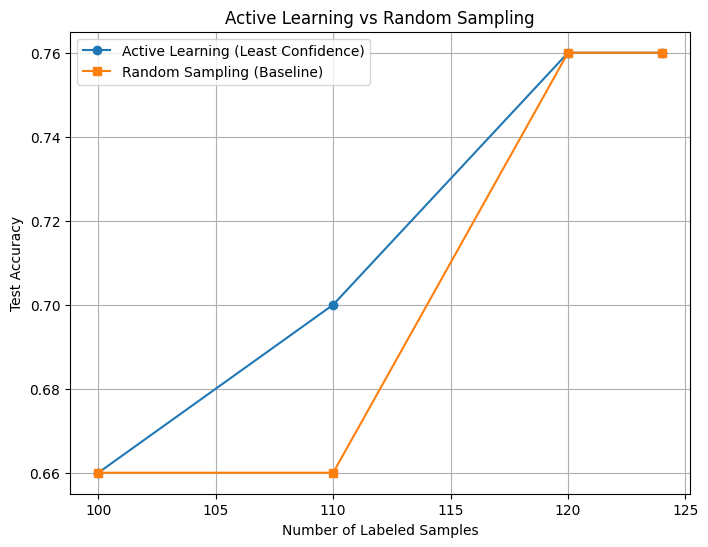

Final Comparison Summary 
Final accuracy (Least Confidence): 0.7600
Final accuracy (Random Sampling):  0.7600

Total labeled samples used: 124


In [46]:
X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer = load_and_process_data()

n_labels_lc, acc_lc = run_active_learning_loop(
    X_seed, y_seed,
    X_pool, y_pool,
    X_test, y_test,
    strategy_func=least_confidence_sampling,
    steps=5,
    batch_size=10
)

# TODO: Run active learning with random sampling (baseline)

n_labels_rand, acc_rand = run_active_learning_loop(
    X_seed, y_seed,
    X_pool, y_pool,
    X_test, y_test,
    strategy_func=random_sampling,
    steps=5,
    batch_size=10
)
# TODO: Plot learning curves of active learning and random sampling wrt to number of samples

plt.figure(figsize=(8, 6))

plt.plot(n_labels_lc, acc_lc, marker='o', label='Active Learning (Least Confidence)')
plt.plot(n_labels_rand, acc_rand, marker='s', label='Random Sampling (Baseline)')

plt.xlabel('Number of Labeled Samples')
plt.ylabel('Test Accuracy')
plt.title('Active Learning vs Random Sampling')
plt.legend()
plt.grid(True)

plt.show()

# TODO: Print comparison summary for active learning and random sampling final accuracy

print("Final Comparison Summary ")
print(f"Final accuracy (Least Confidence): {acc_lc[-1]:.4f}")
print(f"Final accuracy (Random Sampling):  {acc_rand[-1]:.4f}")

print("\nTotal labeled samples used:", n_labels_lc[-1])


## Task 4: AI vs. AI (LLM & Noise Detection) (3 Marks)

**Objective:** Use LLMs for bulk labeling and detect hallucinations.

**Note:**

- Make an account at [open-router](https://openrouter.ai/) and get the API key.
- Use `google/gemini-2.5-flash-lite` (free tier) model as your LLM. Read the documentation on how to use it [here](https://openrouter.ai/google/gemini-2.5-flash-lite/api)
- Set environment variable using .env file and paste your API key in it.

### Part 4.1: LLM Pipeline with Few-Shot Prompting

Design a few-shot prompt with 3 examples from gold standard.
Send remaining unlabeled samples (~150) to Gemini API for labeling.

In [47]:
from dotenv import load_dotenv
import os

key = input("Enter OpenRouter API key (will be saved only in .env): ")

with open(".env", "w") as f:
    f.write(f"OPENROUTER_API_KEY={key}\n")

load_dotenv()
API_KEY = os.getenv("OPENROUTER_API_KEY")
print("API key loaded:", API_KEY is not None)


Enter OpenRouter API key (will be saved only in .env): 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
API key loaded: True


In [48]:
#just to check if api key is loaded
from dotenv import load_dotenv
import os

load_dotenv()  # reads .env
API_KEY = os.getenv("OPENROUTER_API_KEY")
print(API_KEY[:18] + "..." if API_KEY else "API key not found")


sk-or-v1-fbb659e40...


In [49]:

load_dotenv()
API_KEY = os.getenv('OPENROUTER_API_KEY')
SITE_URL = "http://localhost:8000"  #for OpenRouter rankings
SITE_NAME = "Student Lab Assignment"

MODEL_NAME = "google/gemini-2.5-flash-lite"

if not API_KEY:
    print("⚠ Warning: OPENROUTER_API_KEY not found. Please check your .env file.")


def generate_few_shot_prompt(review_text, examples):
    """
    Constructs a few-shot prompt with 3 gold examples + target review.
    Args:
        review_text (str): The review to be labeled
        examples (list): List of 3 example dicts with 'review' and 'label' keys
    Returns:
        str: Formatted prompt string
    """
    prompt_parts = []
    prompt_parts.append(
        "You are a sentiment classifier for movie reviews.\n"
        "Classify each review as exactly one of: Positive, Negative, or Neutral.\n"
        "Respond with only one word: Positive, Negative, or Neutral.\n"
        "Here are some labeled examples:\n"
    )

    for i, ex in enumerate(examples, start=1):
        prompt_parts.append(
            f"Example {i}:\n"
            f"Review: {ex['review']}\n"
            f"Label: {ex['label']}\n\n"
        )

    prompt_parts.append(
        "Now classify the following review.\n"
        "Review: " + review_text + "\n"
        "Label:"
    )

    return "".join(prompt_parts)


def query_openrouter(review_text, examples):
    """
    Sends request to OpenRouter API with retry logic and parsing.

    Args:
        review_text (str): Review to classify
        examples (list): Few-shot examples (list of dicts with 'review' and 'label')

    Returns:
        str: Label ('Positive', 'Negative', or 'Neutral')
             Returns None if API fails or response is invalid
    """
    url = "https://openrouter.ai/api/v1/chat/completions"

    if not API_KEY:
        print("⚠ OPENROUTER_API_KEY missing; cannot call API.")
        return None

    # 1) Set up headers
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": SITE_URL,
        "X-Title": SITE_NAME,
    }

    # 2) Generate prompt
    prompt = generate_few_shot_prompt(review_text, examples)

    # 3) Create payload
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 4,
        "temperature": 0.0,
    }

    # 4) Retry logic
    max_retries = 5
    backoff = 5  # seconds

    for attempt in range(max_retries):
        try:
            resp = requests.post(url, headers=headers, json=payload, timeout=30)

            if resp.status_code == 429:
                print(f"Rate limit hit (429). Sleeping {backoff} seconds...")
                time.sleep(backoff)
                backoff *= 2
                continue

            if resp.status_code >= 400:
                print(f"HTTP error {resp.status_code}: {resp.text[:200]}")
                return None

            data = resp.json()

            # 5) Parse successful response (OpenRouter chat format)
            content = data["choices"][0]["message"]["content"]

            # Some models may return list of segments; normalize to string
            if isinstance(content, list):
                text = "".join(part.get("text", "") for part in content)
            else:
                text = str(content)

            text = text.strip()
            text_lower = text.lower()

            # Normalize to one of the three labels
            if "positive" in text_lower:
                return "Positive"
            if "negative" in text_lower:
                return "Negative"
            if "neutral" in text_lower:
                return "Neutral"

            # Fallback: check if it's just a single word like POSITIVE
            cleaned = text.replace(".", "").strip().capitalize()
            if cleaned in ["Positive", "Negative", "Neutral"]:
                return cleaned

            print("Unrecognized LLM output:", text)
            return None

        except Exception as e:
            print(f"Request error on attempt {attempt+1}: {e}")
            time.sleep(backoff)
            backoff *= 2

    return None


    # pass

# --- MAIN EXECUTION ---

# 1) Load gold standard examples for few-shot prompting
gold_df = pd.read_csv("gold_standard_100.csv")

examples = []
for label in ["Positive", "Negative", "Neutral"]:
    row = gold_df[gold_df["majority label"] == label].iloc[0]
    examples.append({"review": row["review"], "label": row["majority label"]})

print("Using few-shot examples with labels:", [e["label"] for e in examples])

# 2) Load remaining unlabeled reviews (~150, select last 150 from movie_reviews_300.csv)
all_df = pd.read_csv("movie_reviews_300.csv")

gold_texts = set(gold_df["review"].astype(str))
remaining = all_df[~all_df["review"].astype(str).isin(gold_texts)].copy()

# Select last 150 as per instruction
remaining = remaining.tail(150).reset_index(drop=True)
print("Number of reviews to send to LLM:", len(remaining))

# 3) Query OpenRouter for each review (respect RPM ~15)
llm_labels = []

for idx, row in remaining.iterrows():
    review_text = str(row["review"])
    label = query_openrouter(review_text, examples)

    if label is None:
        label = "Neutral"   # safe fallback

    llm_labels.append({"review": review_text, "label": label})
    print(f"Processed {idx+1}/{len(remaining)} -> {label}")
    time.sleep(1)  # light throttle

# 4) Save LLM labels
llm_df = pd.DataFrame(llm_labels)
llm_df.to_csv("llm_labels_150.csv", index=False)

with open("llm_labels_150.json", "w") as f:
    json.dump(llm_labels, f, indent=2)

print(" Saved llm_labels_150.csv and llm_labels_150.json")


Using few-shot examples with labels: ['Positive', 'Negative', 'Neutral']
Number of reviews to send to LLM: 150
Processed 1/150 -> Neutral
Processed 2/150 -> Neutral
Processed 3/150 -> Negative
Processed 4/150 -> Neutral
Processed 5/150 -> Positive
Processed 6/150 -> Negative
Processed 7/150 -> Positive
Processed 8/150 -> Neutral
Processed 9/150 -> Neutral
Processed 10/150 -> Neutral
Processed 11/150 -> Positive
Processed 12/150 -> Neutral
Processed 13/150 -> Positive
Processed 14/150 -> Positive
Processed 15/150 -> Negative
Processed 16/150 -> Negative
Processed 17/150 -> Positive
Processed 18/150 -> Positive
Processed 19/150 -> Neutral
Processed 20/150 -> Neutral
Processed 21/150 -> Neutral
Processed 22/150 -> Neutral
Processed 23/150 -> Positive
Processed 24/150 -> Neutral
Processed 25/150 -> Positive
Processed 26/150 -> Negative
Processed 27/150 -> Negative
Processed 28/150 -> Negative
Processed 29/150 -> Neutral
Processed 30/150 -> Neutral
Processed 31/150 -> Neutral
Processed 32/1

### Part 4.2: Noise Hunting (Cleanlab Logic)

Train a Logistic Regression model on LLM-labeled data.
Identify "High Confidence Disagreements" where the model is very confident (>0.80) but disagrees with the LLM label.

In [50]:
def find_label_errors(llm_labels, model_probs, review_texts, threshold=0.90):
    """
    Detects high-confidence disagreements between model predictions and LLM labels.
    This implements Cleanlab logic: find cases where model is confident but disagrees with LLM.

    Args:
        llm_labels: List/array of labels from Gemini (numeric: 0=Negative, 1=Positive, 2=Neutral, or strings)
        model_probs: Probability matrix from Logistic Regression (shape: N_samples, N_classes)
        review_texts: List of review texts (for display)
        threshold: Confidence threshold (default 0.90)

    Returns:
        list: List of dictionaries with suspicious review information
              Each dict contains: 'index', 'text', 'llm_label', 'model_pred', 'confidence'
    """
    # Get model predictions from probabilities
    preds = np.argmax(model_probs, axis=1)

    # Get model confidence (max probability) for each sample
    confidences = np.max(model_probs, axis=1)

    # Convert llm_labels to numeric if they are strings
    # Map 'Positive'->1, 'Negative'->0, 'Neutral'->2
    if isinstance(llm_labels[0], str):
        mapping = {
            "Negative": 0, "negative": 0,
            "Positive": 1, "positive": 1,
            "Neutral": 2,  "neutral": 2,
        }
        llm_numeric = np.array([mapping.get(lbl, 2) for lbl in llm_labels])
    else:
        llm_numeric = np.array(llm_labels)

    # Find disagreements where model is confident and disagrees with LLM
    disagreement_mask = (preds != llm_numeric) & (confidences > threshold)

    # Create list of suspicious reviews with all relevant information
    suspicious = []
    idxs = np.where(disagreement_mask)[0]
    for idx in idxs:
        suspicious.append({
            "index": int(idx),
            "text": review_texts[idx],
            "llm_label": int(llm_numeric[idx]),
            "model_pred": int(preds[idx]),
            "confidence": float(confidences[idx]),
        })

    # Sort by confidence (highest first) to find most egregious errors
    suspicious_sorted = sorted(suspicious, key=lambda x: x["confidence"], reverse=True)

    # Return list of suspicious reviews
    return suspicious_sorted


# --- MAIN EXECUTION FOR TASK 4.2 ---

# Load LLM labels in dataframe
llm_df = pd.read_csv("llm_labels_150.csv")
print("LLM labels shape:", llm_df.shape)

# Ensure correct columns
reviews = llm_df["review"].astype(str).values
if "label" in llm_df.columns:
    llm_labels_text = llm_df["label"].astype(str).values
else:
    llm_labels_text = llm_df["sentiment"].astype(str).values

# Vectorize LLM-labeled reviews (use same vectorizer from Task 3)
# Make sure you already ran:
# X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer = load_and_process_data()
X_llm = vectorizer.transform(reviews).toarray()

# Train Logistic Regression on LLM-labeled data (same config as Task 3)
label_mapping = {
    "Negative": 0, "negative": 0,
    "Positive": 1, "positive": 1,
    "Neutral": 2,  "neutral": 2,
}
y_llm = np.array([label_mapping.get(lbl, 2) for lbl in llm_labels_text])

clf_llm = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
)
clf_llm.fit(X_llm, y_llm)

# Get probabilities on the same data (self-check)
model_probs = clf_llm.predict_proba(X_llm)

# Find label errors using your function
suspicious_reviews = find_label_errors(
    llm_labels=llm_labels_text,
    model_probs=model_probs,
    review_texts=reviews,
    threshold=0.90,
)

print(f"Found {len(suspicious_reviews)} high-confidence disagreements.\n")

# Print top 5 suspicious reviews (if <5, print all)
top_k = min(5, len(suspicious_reviews))
for i in range(top_k):
    r = suspicious_reviews[i]
    print(f"{i+1}. Index {r['index']}, conf={r['confidence']:.3f}")
    print(f"   Text      : {r['text']}")
    print(f"   LLM label : {llm_labels_text[r['index']]}")
    inv_map = {0: "Negative", 1: "Positive", 2: "Neutral"}
    print(f"   Model pred: {inv_map[r['model_pred']]}")
    print()


LLM labels shape: (150, 2)
Found 0 high-confidence disagreements.



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Deliverables

**Submission Checklist:**
- [ ] Completed Jupyter Notebook with all tasks (Tasks 1-4)
- [ ] Include your label-studio annotation interface screenshot.
- [ ] gold_standard_100.csv
- [ ] weak_labels_200.csv
- [ ] llm_labels_150.json